# Variational Nonlinear Chirp Mode Decomposition (VNCMD)

> **Original paper**: Chen, S., Dong, X., Peng, Z., Zhang, W. & Meng, G. (2017). *Nonlinear Chirp Mode Decomposition: A Variational Method*. IEEE Transactions on Signal Processing, 65(22), 6024–6037.
>
> MATLAB reference: [File Exchange — VNCMD](https://www.mathworks.com/matlabcentral/fileexchange/64292-variational-nonlinear-chirp-mode-decomposition)

This notebook explains **why VNCMD was introduced**, how its variational model differs from VMD, and reproduces the MATLAB demos (intersecting chirps; noisy chirps) with PySDKit.

---

## Contents

1. What VMD cannot do well  
2. Nonlinear chirp modes and demodulation  
3. Variational model and ADMM-like updates  
4. PySDKit API  
5. Experiment 1: noise-free intersecting IFs (MATLAB demo 1)  
6. Experiment 2: strong noise (MATLAB demo 2)  
7. Summary  


## 1. What VMD cannot do well

Classical **VMD** assumes each mode is *narrow-band around a nearly constant center frequency* $\omega_k$. It is excellent for tones and mildly modulated signals, but it struggles when:

| Limitation of VMD | Consequence |
|-------------------|-------------|
| Constant / slowly varying $\omega_k$ | Fast **chirps** are smeared across bands |
| Modes must stay spectrally separated | **Crossing instantaneous frequencies** cause mode mixing |
| Bandwidth prior is isotropic in frequency | Wideband FM energy is over-penalized or split |

**VNCMD** targets **nonlinear chirp modes** whose instantaneous frequency (IF) can vary strongly — including **crossing IFs** — by jointly estimating:

- the mode waveforms $s_k(t)$,  
- their instantaneous amplitudes $a_k(t)$,  
- and their instantaneous frequencies $f_k(t)$.


## 2. Nonlinear chirp mode model

A chirp mode is written as an AM–FM signal
$$
s_k(t)=a_k(t)\cos\Bigl(2\pi\int_0^t f_k(\tau)\,\mathrm{d}\tau+\phi_k\Bigr).
$$

VNCMD uses **demodulation operators** with carriers built from the current IF estimate $\tilde f_k$:
$$
\begin{aligned}
\cos\theta_k(t)&=\cos\Bigl(2\pi\int \tilde f_k\Bigr),&
\sin\theta_k(t)&=\sin\Bigl(2\pi\int \tilde f_k\Bigr),
\end{aligned}
$$
and recovers two smooth quadrature envelopes $x_k(t), y_k(t)$ such that
$$
s_k(t)=x_k(t)\cos\theta_k(t)+y_k(t)\sin\theta_k(t),\qquad
a_k(t)=\sqrt{x_k(t)^2+y_k(t)^2}.
$$

If $\tilde f_k$ is close to the true IF, $x_k$ and $y_k$ become **narrow-band / smooth**, which is exactly what the quadratic difference penalty encourages.


## 3. Variational principle (paper / MATLAB algorithm)

VNCMD solves a constrained variational problem that:

1. Forces $x_k,y_k$ to be smooth (second-order difference operator $\mathbf{D}$);  
2. Matches the residual $g-\sum_k s_k$ to a noise slack $u$ (with $\|u\|_2\le\sqrt{N\sigma^2}$ when $\mathrm{var}=\sigma^2>0$);  
3. Updates the IF by **arctangent demodulation**
$$
\Delta f_k
=
\frac{x_k y_k'-y_k x_k'}{2\pi\,(x_k^2+y_k^2)},
$$
then low-pass filters $\Delta f_k$ (parameter $\beta$) and sets
$$
\tilde f_k\leftarrow \tilde f_k-\tfrac12\Delta f_k.
$$

**Algorithm sketch (matches `VNCMD.m`)**

1. Initialize IF guesses $\tilde f_k(t)$ (constant ridges, or TF ridge detection).  
2. Build $\sin/\cos$ carriers; solve for $x_k,y_k$ with bandwidth weight $\alpha$.  
3. Iterate: project noise $u$, update $x_k,y_k$, update IF, refresh carriers, dual ascent on $\lambda$.  
4. Optional **restart** if the residual energy exceeds $\|g\|_2$.  

| Parameter | Role |
|-----------|------|
| `alpha` | Filtering bandwidth (smaller → narrower) |
| `beta` | Smoothness of IF increments |
| `var` | Noise variance; `0` drops the slack $u$ |
| `eIF` | Initial IF matrix, shape `(K, N)` |


## 4. PySDKit API

```python
from pysdkit import VNCMD

vncmd = VNCMD(fs=2000, alpha=5e-6, beta=1e-6, var=0.0, tol=1e-8, max_iter=300)
modes, IF, IA = vncmd.fit_transform(signal, eIF=iniIF)   # (K,N), (K,N), (K,N)
IFhist, modehist, IA = vncmd.fit_transform(signal, eIF=iniIF, return_all=True)
```


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

from pysdkit import VNCMD

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float)
    est = np.asarray(est, dtype=float)
    return float(np.linalg.norm(est - ref) / (np.linalg.norm(ref) + 1e-16))


def snr_db(clean, estimate):
    clean = np.asarray(clean, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    return float(
        10 * np.log10(np.sum(clean**2) / (np.sum((clean - estimate) ** 2) + 1e-16))
    )

## 5. Experiment 1 — Noise-free intersecting IFs (MATLAB demo 1)

Two amplitude-modulated cubic chirps whose IFs **cross**. Constant IF initializations at 700 Hz and 20 Hz are intentionally rough — VNCMD still locks onto both ridges.


N = 2001 | duration = 1.0 s


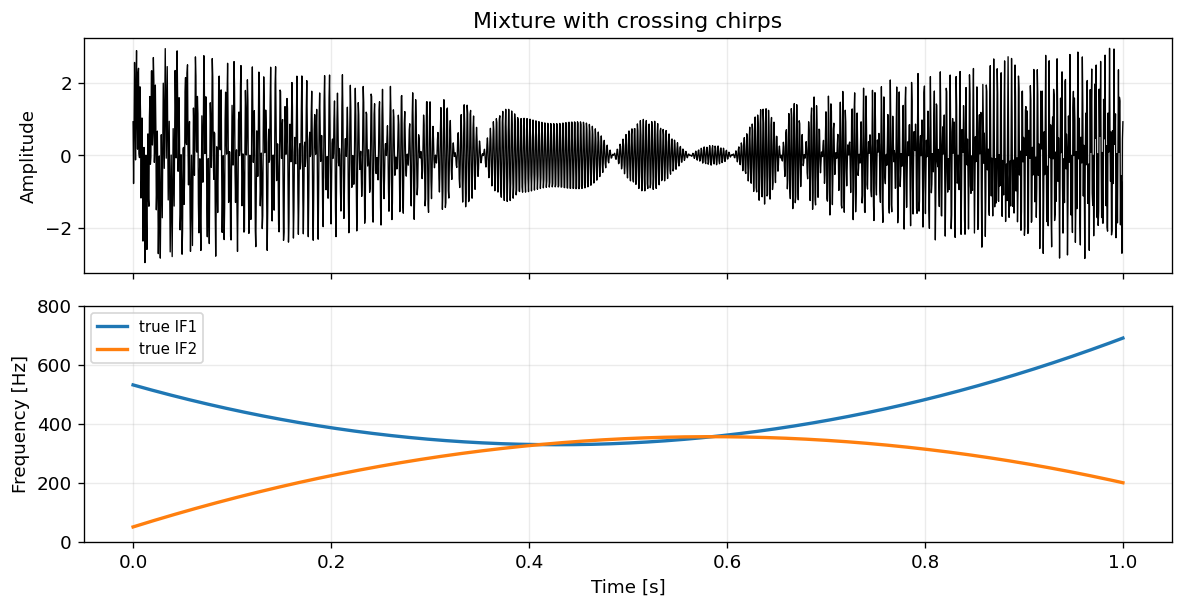

In [2]:
fs = 2000.0
t = np.arange(0, 1 + 0.5 / fs, 1.0 / fs)  # MATLAB: 0:1/fs:1

sig1 = (1 + 0.5 * np.cos(2 * np.pi * t)) * np.cos(
    2 * np.pi * (0.2 + 532 * t - 474 * t**2 + 369 * t**3)
)
if1 = 532 - 948 * t + 1107 * t**2

sig2 = (1 + 0.5 * np.cos(2 * np.pi * t)) * np.cos(
    2 * np.pi * (0.8 + 50 * t + 525 * t**2 - 300 * t**3)
)
if2 = 50 + 1050 * t - 900 * t**2

sig = sig1 + sig2
print("N =", len(t), "| duration =", t[-1], "s")

fig, axs = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
axs[0].plot(t, sig, "k", lw=0.8)
axs[0].set_ylabel("Amplitude")
axs[0].set_title("Mixture with crossing chirps")
axs[1].plot(t, if1, lw=2, label="true IF1")
axs[1].plot(t, if2, lw=2, label="true IF2")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_xlabel("Time [s]")
axs[1].legend(fontsize=9)
axs[1].set_ylim(0, 800)
plt.tight_layout()
plt.show()

Relative IF errors:
  RE1 = 0.0006959778175170061
  RE2 = 0.0008543103879749206
Mode reconstruction SNR [dB]:
  mode1 = 43.83008173413211
  mode2 = 45.318984816738286


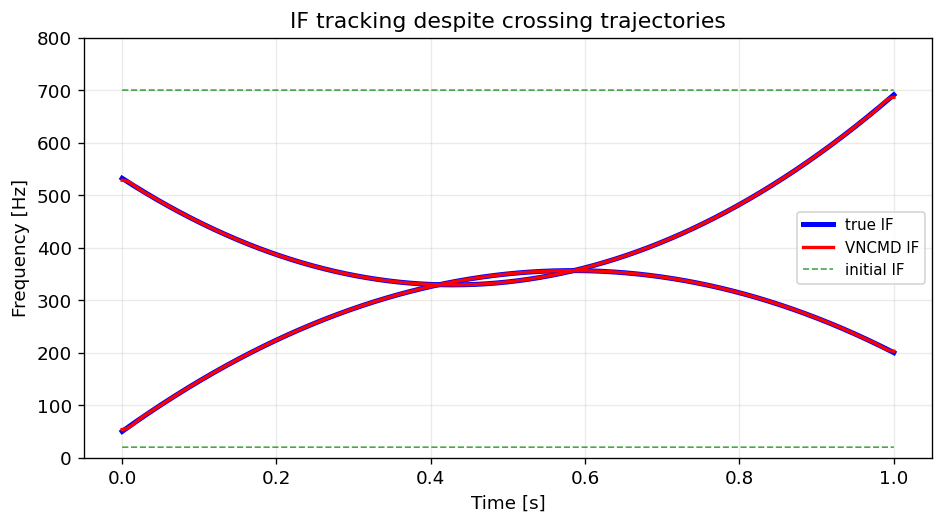

In [3]:
iniIF = np.vstack([700 * np.ones(t.size), 20 * np.ones(t.size)])
vncmd = VNCMD(fs=fs, alpha=5e-6, beta=1e-6, var=0.0, tol=1e-8, max_iter=300)
modes, IF, IA = vncmd.fit_transform(sig, eIF=iniIF)

print("Relative IF errors:")
print("  RE1 =", relative_error(if1, IF[0]))
print("  RE2 =", relative_error(if2, IF[1]))
print("Mode reconstruction SNR [dB]:")
print("  mode1 =", snr_db(sig1, modes[0]))
print("  mode2 =", snr_db(sig2, modes[1]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t, if1, "b", lw=3, label="true IF")
ax.plot(t, if2, "b", lw=3)
ax.plot(t, IF[0], "r", lw=2, label="VNCMD IF")
ax.plot(t, IF[1], "r", lw=2)
ax.plot(t, iniIF[0], "g--", lw=1, alpha=0.7, label="initial IF")
ax.plot(t, iniIF[1], "g--", lw=1, alpha=0.7)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("IF tracking despite crossing trajectories")
ax.set_ylim(0, 800)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

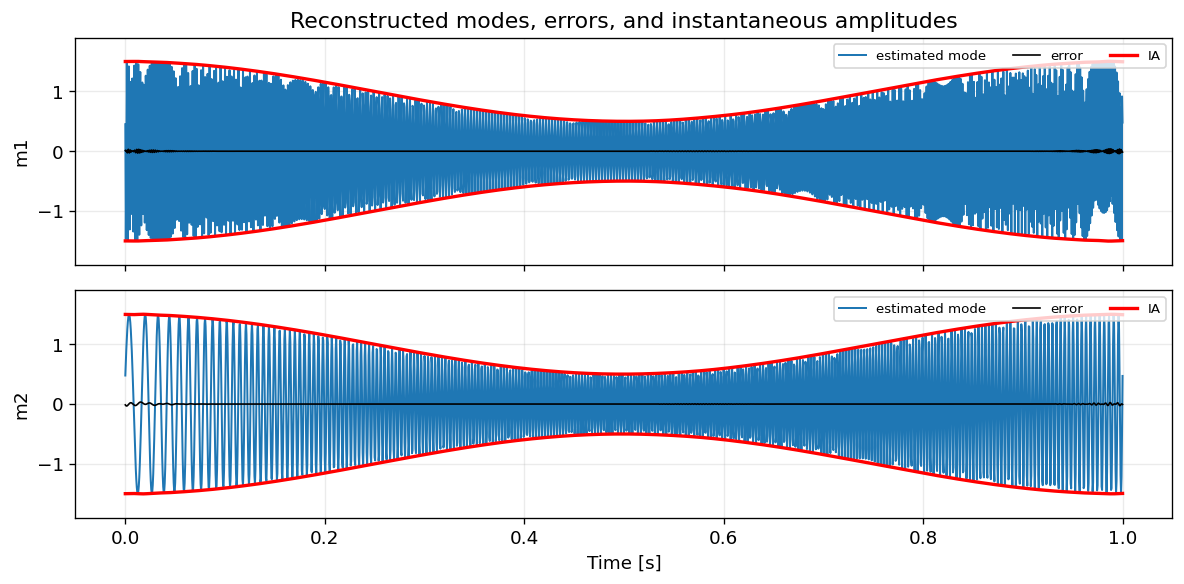

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(10, 5.0), sharex=True)
for k, (true, est, ia, name) in enumerate(
    [(sig1, modes[0], IA[0], "m1"), (sig2, modes[1], IA[1], "m2")]
):
    axs[k].plot(t, est, lw=1.2, label="estimated mode")
    axs[k].plot(t, true - est, "k", lw=1.0, label="error")
    axs[k].plot(t, ia, "r", lw=2.0, label="IA")
    axs[k].plot(t, -ia, "r", lw=2.0)
    axs[k].set_ylabel(name)
    axs[k].legend(fontsize=8, loc="upper right", ncol=3)
    axs[k].set_ylim(-1.9, 1.9)
axs[-1].set_xlabel("Time [s]")
axs[0].set_title("Reconstructed modes, errors, and instantaneous amplitudes")
plt.tight_layout()
plt.show()

## 6. Experiment 2 — Strong noise (MATLAB demo 2)

Two polynomial chirps in heavy Gaussian noise ($\sigma=1$, mode SNRs about −3 dB). Set `var = σ²` so the projection slack absorbs the noise floor.


Approx. mode SNR [dB]: -2.9626247411463775


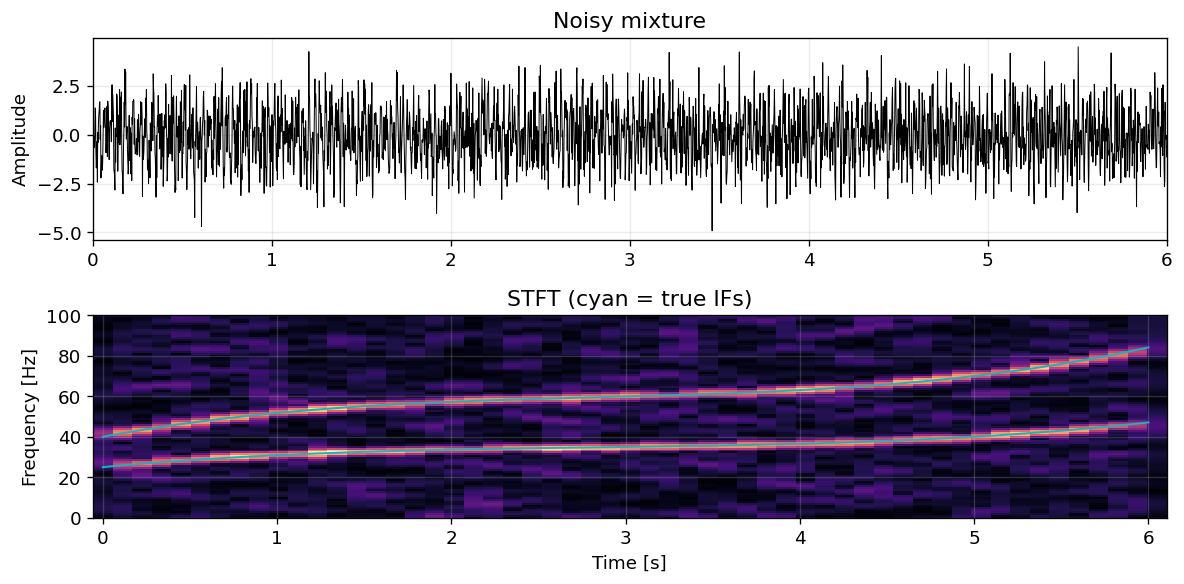

In [5]:
fs_n = 500.0
t_n = np.arange(0, 6 + 0.5 / fs_n, 1.0 / fs_n)

sig1_n = np.cos(
    2 * np.pi * (1.3 + 25 * t_n + 4 * t_n**2 - 0.8 * t_n**3 + 0.07 * t_n**4)
)
if1_n = 25 + 8 * t_n - 2.4 * t_n**2 + 0.28 * t_n**3
sig2_n = np.cos(
    2 * np.pi * (2.6 + 40 * t_n + 8 * t_n**2 - 1.6 * t_n**3 + 0.14 * t_n**4)
)
if2_n = 40 + 16 * t_n - 4.8 * t_n**2 + 0.56 * t_n**3

rng = np.random.default_rng(0)
std = 1.0
noise = rng.normal(0.0, std, size=t_n.size)
sig_n = sig1_n + sig2_n + noise
print("Approx. mode SNR [dB]:", snr_db(sig1_n, sig1_n + noise))

fig, axs = plt.subplots(2, 1, figsize=(10, 5.0), sharex=False)
axs[0].plot(t_n, sig_n, "k", lw=0.6)
axs[0].set_title("Noisy mixture")
axs[0].set_ylabel("Amplitude")
axs[0].set_xlim(0, 6)
# simple spectrogram-like STFT magnitude for intuition
from scipy.signal import stft

f_s, t_s, Z = stft(sig_n, fs=fs_n, nperseg=256, noverlap=200, nfft=512)
axs[1].pcolormesh(t_s, f_s, np.abs(Z), shading="auto", cmap="magma")
axs[1].plot(t_n, if1_n, "c", lw=1.2)
axs[1].plot(t_n, if2_n, "c", lw=1.2)
axs[1].set_ylim(0, 100)
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_xlabel("Time [s]")
axs[1].set_title("STFT (cyan = true IFs)")
plt.tight_layout()
plt.show()

Relative IF errors:
  RE1 = 0.004605767084766533
  RE2 = 0.004341836990744784
Reconstructed-mode SNR [dB]:
  mode1 = 9.8062022600643
  mode2 = 10.600679489056212
Residual std (≈ noise std=1): 0.9994058232668303


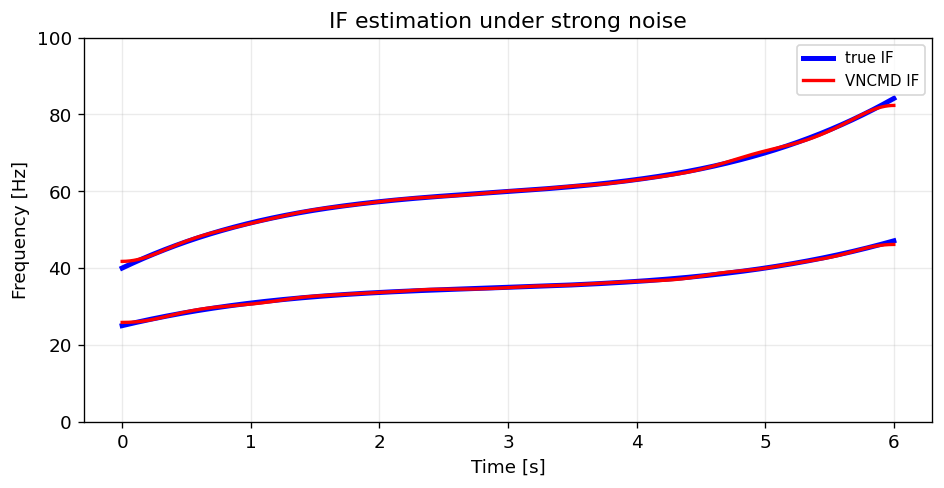

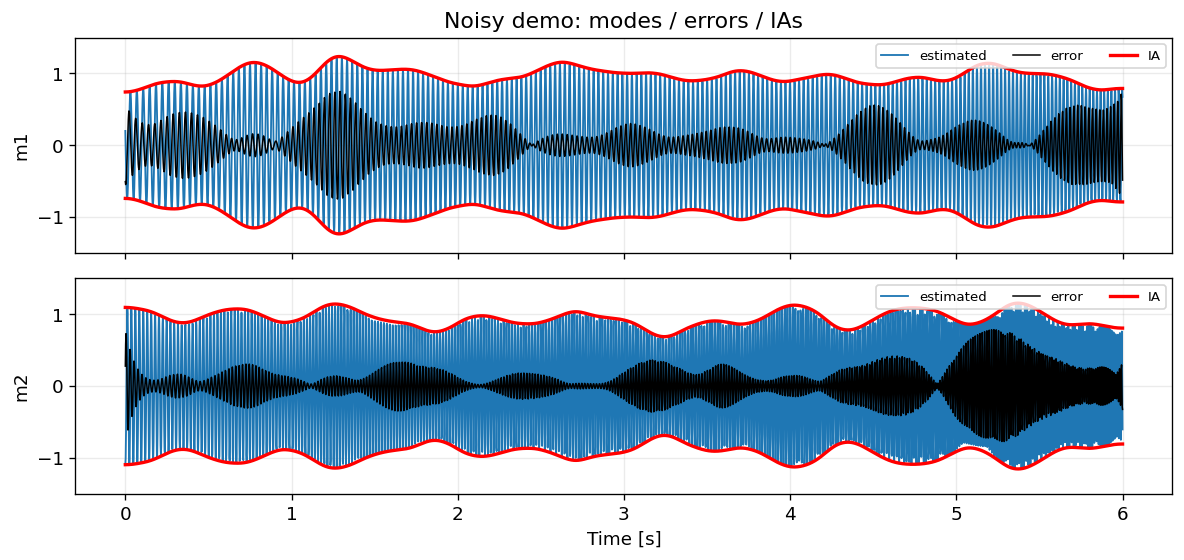

In [6]:
iniIF_n = np.vstack([30 * np.ones(t_n.size), 60 * np.ones(t_n.size)])
vncmd_n = VNCMD(
    fs=fs_n,
    alpha=3e-4,
    beta=1e-9,
    var=std**2,
    tol=1e-8,
    max_iter=300,
)
modes_n, IF_n, IA_n = vncmd_n.fit_transform(sig_n, eIF=iniIF_n)

print("Relative IF errors:")
print("  RE1 =", relative_error(if1_n, IF_n[0]))
print("  RE2 =", relative_error(if2_n, IF_n[1]))
print("Reconstructed-mode SNR [dB]:")
print("  mode1 =", snr_db(sig1_n, modes_n[0]))
print("  mode2 =", snr_db(sig2_n, modes_n[1]))
residue = sig_n - modes_n.sum(axis=0)
print("Residual std (≈ noise std=1):", float(np.std(residue)))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(t_n, if1_n, "b", lw=3)
ax.plot(t_n, if2_n, "b", lw=3, label="true IF")
ax.plot(t_n, IF_n[0], "r", lw=2)
ax.plot(t_n, IF_n[1], "r", lw=2, label="VNCMD IF")
ax.set_ylim(0, 100)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("IF estimation under strong noise")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True)
for ax, true, est, ia, name in [
    (axs[0], sig1_n, modes_n[0], IA_n[0], "m1"),
    (axs[1], sig2_n, modes_n[1], IA_n[1], "m2"),
]:
    ax.plot(t_n, est, lw=1.1, label="estimated")
    ax.plot(t_n, true - est, "k", lw=0.9, label="error")
    ax.plot(t_n, ia, "r", lw=2.0, label="IA")
    ax.plot(t_n, -ia, "r", lw=2.0)
    ax.set_ylabel(name)
    ax.legend(fontsize=8, ncol=3, loc="upper right")
    ax.set_ylim(-1.5, 1.5)
axs[-1].set_xlabel("Time [s]")
axs[0].set_title("Noisy demo: modes / errors / IAs")
plt.tight_layout()
plt.show()

## 7. Summary

| Aspect | VMD | VNCMD |
|--------|-----|-------|
| Mode model | Narrow-band around $\omega_k$ | Nonlinear chirp $a_k(t),\ f_k(t)$ |
| Crossing IFs | Often mixes / fails | Designed to track crossings |
| Wideband FM | Limited | Demodulation + smooth quadratures |
| Noise | Quadratic fidelity / $\tau=0$ | Explicit projection slack $u$ (`var`) |

**Takeaways**

1. VNCMD extends variational decomposition from tones to **fast / crossing chirps**.  
2. Good **initial IFs** help, but constant guesses can still work (demo 1).  
3. Tune `alpha` (bandwidth) and `beta` (IF smoothness); set `var` to the noise variance when noise is significant.  

### One-liner

```python
from pysdkit import VNCMD
modes, IF, IA = VNCMD(fs=fs, alpha=5e-6, beta=1e-6, var=0.0).fit_transform(x, eIF=iniIF)
```
